# Planning a Coastal Survey Aircraft Tracking Mission from Joint Assimilation of Heterogeneous Sensor Data

## Roman Branovets, Skoltech, 2025

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, atan, sin, cos, pi

### Trajectory generation

**True trajectory of turboprop aircraft path**

Generating a true trajectory of the coordinates $𝒙_𝒊$ and $y_i$ of an aircraft's motion. The trajectory
will consist of 500 points, starting with initial conditions $𝑥_0 = 1000 m$. ,$y_0 = 1000 m$., $𝑉_x = 100$ m/s, $𝑉_y = 100$ m/s. and a time
step $𝑇 = 2$ s.

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}^x T + \frac{a_{i-1}^x T^2}{2} \\
V_i^x &= V_{i-1}^x + a_{i-1}^x T \\
y_i &= y_{i-1} + V_{i-1}^y T + \frac{a_{i-1}^y T^2}{2} \\
V_i^y &= V_{i-1}^y + a_{i-1}^y T
\end{aligned}
$$

In [34]:
#generating_trajectory
steps=500
x_real=np.zeros(steps)
vx_real=np.zeros(steps)
y_real=np.zeros(steps)
vy_real=np.zeros(steps)
t=2
x_real[0]=1000
y_real[0]=1000
vx_real[0]=100
vy_real[0]=100
a=np.random.normal(0,0.3,steps)
for i in range(1,steps):
    x_real[i]=x_real[i-1]+vx_real[i-1]*t+(a[i-1]*(t**2))/2
    vx_real[i]=vx_real[i-1]+a[i-1]*t
    y_real[i]=y_real[i-1]+vy_real[i-1]*t+(a[i-1]*(t**2))/2
    vy_real[i]=vy_real[i-1]+a[i-1]*t

**True trajectory of turboprop aircraft path in polar coordinate system**

Generating the true values of range D (meters) and azimuth $\beta$ (radians)

$$
\begin{aligned}
D_i &= \sqrt{x_i^2 + y_i^2} \\
\beta_i &= \arctan\left(\frac{x_i}{y_i}\right)
\end{aligned}
$$

In [35]:
#trajectory_in_polar_coordinate_system
D_real=np.zeros(steps)
beta_real=np.zeros(steps)
for i in range(0,steps):
    D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
    beta_real[i] = atan(x_real[i]/y_real[i])

Let's plot the motion in polar coordinate system

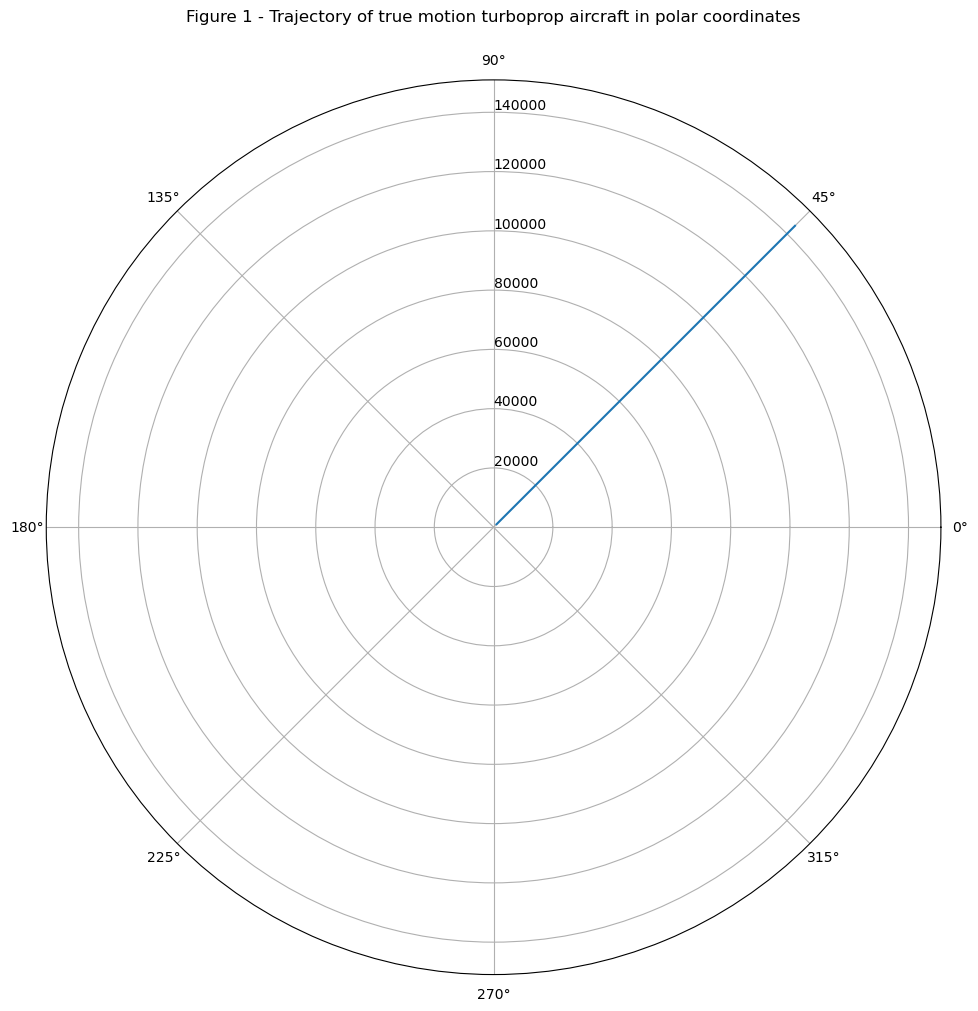

In [36]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real)
ax.grid(True)
ax.set_rlabel_position(90) 
ax.set_title("Figure 1 - Trajectory of true motion turboprop aircraft in polar coordinates", va='bottom',pad=40)
plt.show()

**Measurements**  
Generate measured values from the first observer as follows:  

\
\begin{align*}
D_{i}^{m} &= D_{i} + \eta _{i}^{D} \\
\beta _{i}^{m} &= \beta _{i} + \eta _{i}^{\beta}
\end{align*}
\
$\eta _{i}^{D}$ and $\eta _{i}^{\beta }$ are variances of the measurement noises $\sigma _{D}$=50 m and $\sigma _{\beta}$ = 0.004 rad

In [37]:
#generating_measurements_of_polar_from_the_first_observer
D=np.zeros(steps)
beta1=np.zeros(steps)
D_plot=np.array([])
beta1_plot=np.array([])
for i in range(0,steps-1,2):
    D[i]=D_real[i]+np.random.normal(0,50)
    beta1[i]=beta_real[i]+np.random.normal(0,0.004)
    D_plot=np.append(D_plot,D[i])
    beta1_plot=np.append(beta1_plot,beta1[i])

Generate measured values from the second observer as follows:  

\
\begin{align*}
\beta _{i}^{m} &= \beta _{i} + \eta _{i}^{\beta}
\end{align*}
\
$\eta _{i}^{\beta }$ is variance of the measurement noise $\sigma _{\beta_{add}}$ = 0.001 rad

In [38]:
#generating_measurements_of_polar_from_the_second_observer
beta2=np.zeros(steps)
beta2_plot=np.array([])
for i in range(3,steps,2):
    beta2[i]=beta_real[i]+np.random.normal(0,0.001)
    beta2_plot=np.append(beta2_plot,beta2[i])

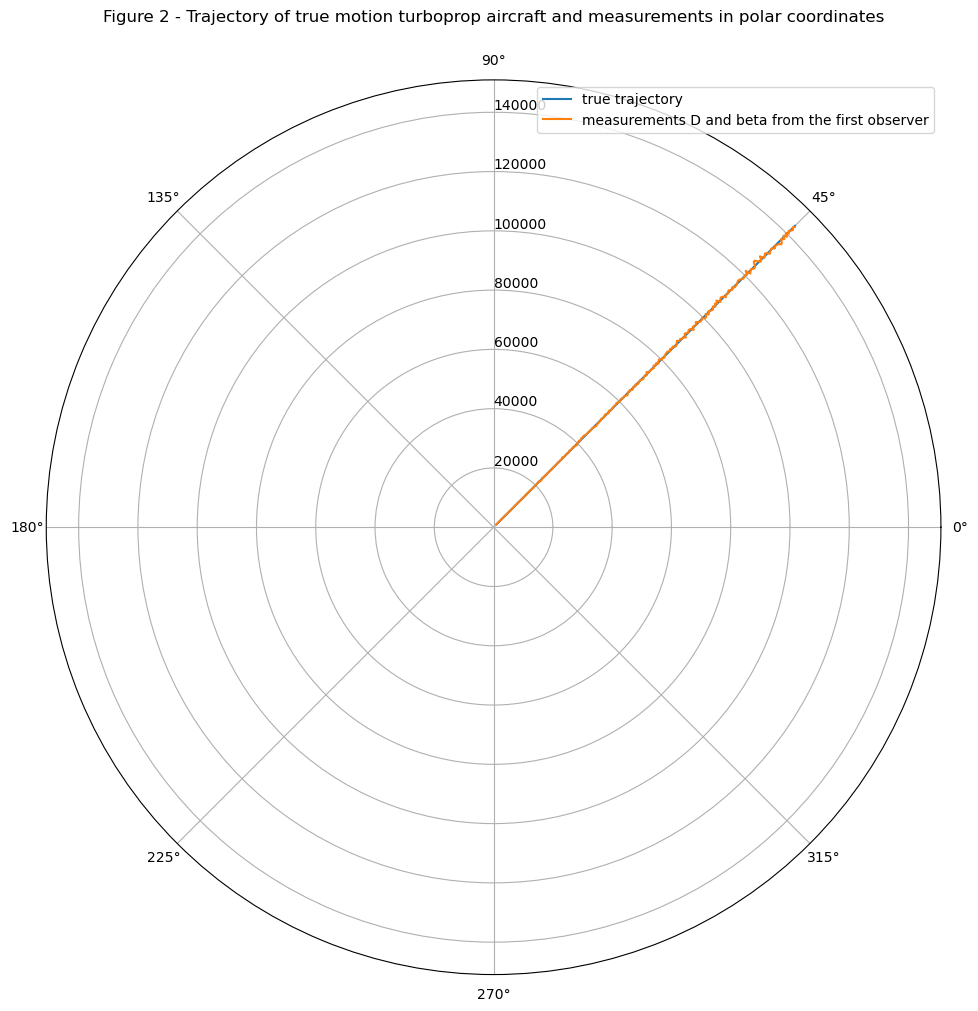

In [39]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trajectory')
ax.plot(beta1_plot, D_plot, label='measurements D and beta from the first observer')
ax.grid(True)
ax.legend()
ax.set_rlabel_position(90) 
ax.set_title("Figure 2 - Trajectory of true motion turboprop aircraft and measurements in polar coordinates", va='bottom',pad=40)
plt.show()

Create the measurement vector z from measurements of range $D$ and azimuth $\beta$

In [40]:
z1 = np.zeros((steps, 2, 1))
z2 = np.zeros((steps, 1, 1))
for i in range(steps):
    z1[i] = np.array([[D[i]], [beta1[i]]])
    z2[i] = np.array([[beta2[i]]])

**Extended Kalman Filter**  
Let's develop Extended Kalman Filter algorithm

In [41]:
#transition matrix
fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
#state vector
X = np.zeros((steps, 4, 1))
dh1=np.zeros((steps,2,4))
h1=np.zeros((steps,2,1))
dh2=np.zeros((steps,1,4))
h2=np.zeros((steps,1,1))
#Initial filtered estimate
X[0]=np.matrix([[D[2]*sin(beta1[2])],[(D[2]*sin(beta1[2])-D[0]*sin(beta1[0]))/(2*t)],[D[2]*cos(beta1[2])],[(D[2]*cos(beta1[2])-D[0]*cos(beta1[0]))/(2*t)]])
X[1]=np.matrix(X[0])
X[2]=np.matrix(X[1])
#Filtration error covariance matrix
P=np.zeros((steps, 4, 4))
P[0]=np.matrix([[10**4, 0,0,0], [0, 10**4,0,0],[0,0,10**4,0],[0,0,0,10**4]])
D_pred=np.zeros(steps)
D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
beta_pred=np.zeros(steps)
beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
D_filt=np.zeros(steps)
D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
beta_filt=np.zeros(steps)
beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
#Covariance matrix
g=np.matrix([[(t**2)/2,0],[t,0],[0,(t**2)/2],[0,t]])
K1 = np.zeros((steps, 4, 2))
K2 = np.zeros((steps, 4, 1))
R1=np.matrix([[50**2,0],[0,0.004*2]])
R2=np.matrix([[0.001*2]])
Q=np.matrix(g@g.T*(0.3**2))
for i in range(3,steps):
    if i%2==0:
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
        #step of filtration
        h1[i]=np.matrix([[sqrt(X[i,0,0]**2+X[i,2,0]**2)],[atan(X[i,0,0]/X[i,2,0])]])
        dh1[i]=np.matrix([[X[i,0,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0,X[i,2,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0],[X[i,2,0]/(X[i,0,0]**2+X[i,2,0]**2),0,-X[i,0,0]/(X[i,0,0]**2+X[i,2,0]**2),0]])
        E=dh1[i]@P[i]@dh1[i].T + R1
        K1[i]=P[i]@dh1[i].T@np.linalg.inv(E)
        X[i]=X[i]+K1[i]@(z1[i]-h1[i])
        P[i]=(np.identity(4)-K1[i]@dh1[i])@P[i]
        D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
    else:
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
        #step of filtration
        h2[i]=np.matrix([[atan(X[i,0,0]/X[i,2,0])]])
        dh2[i]=np.matrix([[X[i,2,0]/(X[i,0,0]**2+X[i,2,0]**2),0,-X[i,0,0]/(X[i,0,0]**2+X[i,2,0]**2),0]])
        E=dh2[i]@P[i]@dh2[i].T + R2
        K2[i]=P[i]@dh2[i].T@np.linalg.inv(E)
        X[i]=X[i]+K2[i]@(z2[i]-h2[i])
        P[i]=(np.identity(4)-K2[i]@dh2[i])@P[i]
        D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_filt[i]=atan(X[i,0,0]/X[i,2,0])

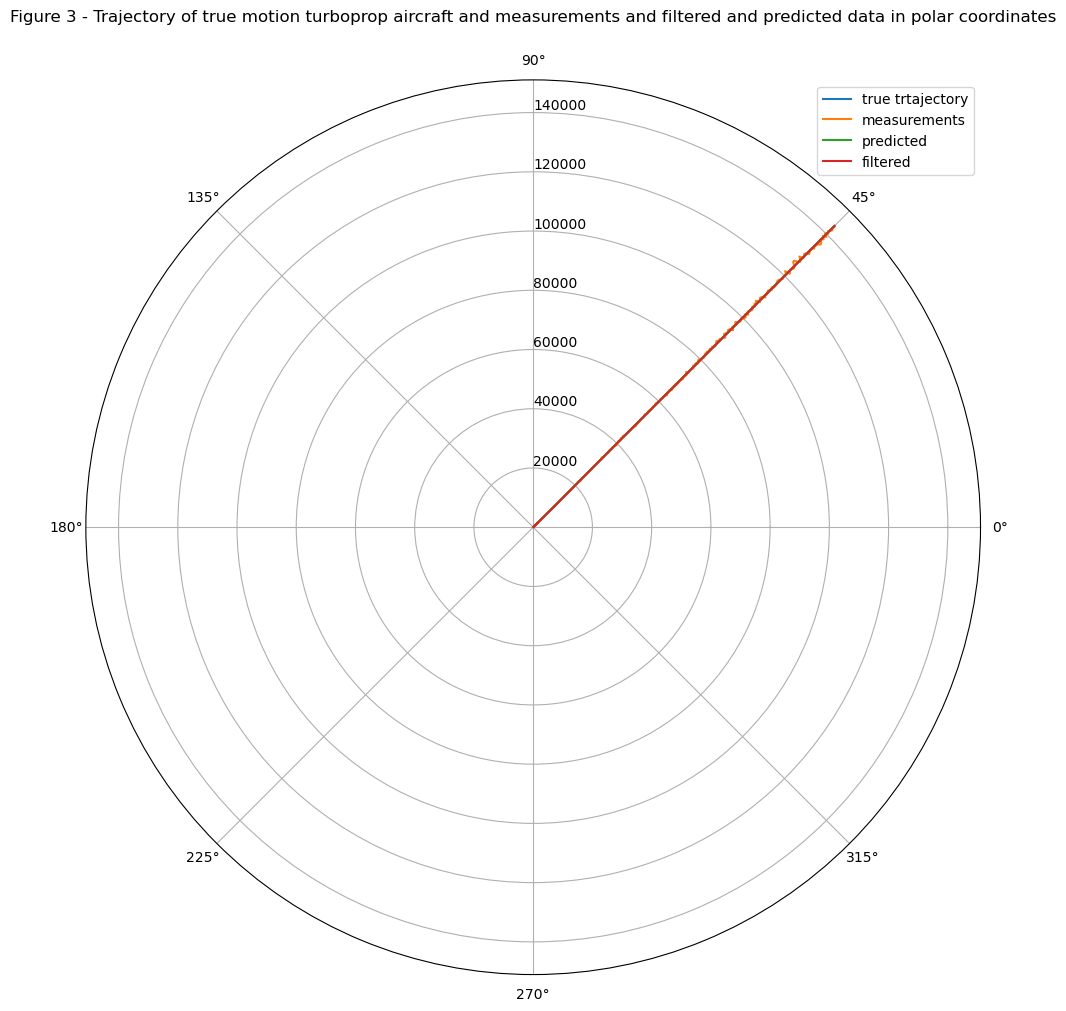

In [42]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta1_plot, D_plot, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_rlabel_position(90) 
ax.set_title("Figure 3 - Trajectory of true motion turboprop aircraft and measurements and filtered and predicted data in polar coordinates", va='bottom',pad=40)
plt.show()

Let's zoom in a plot

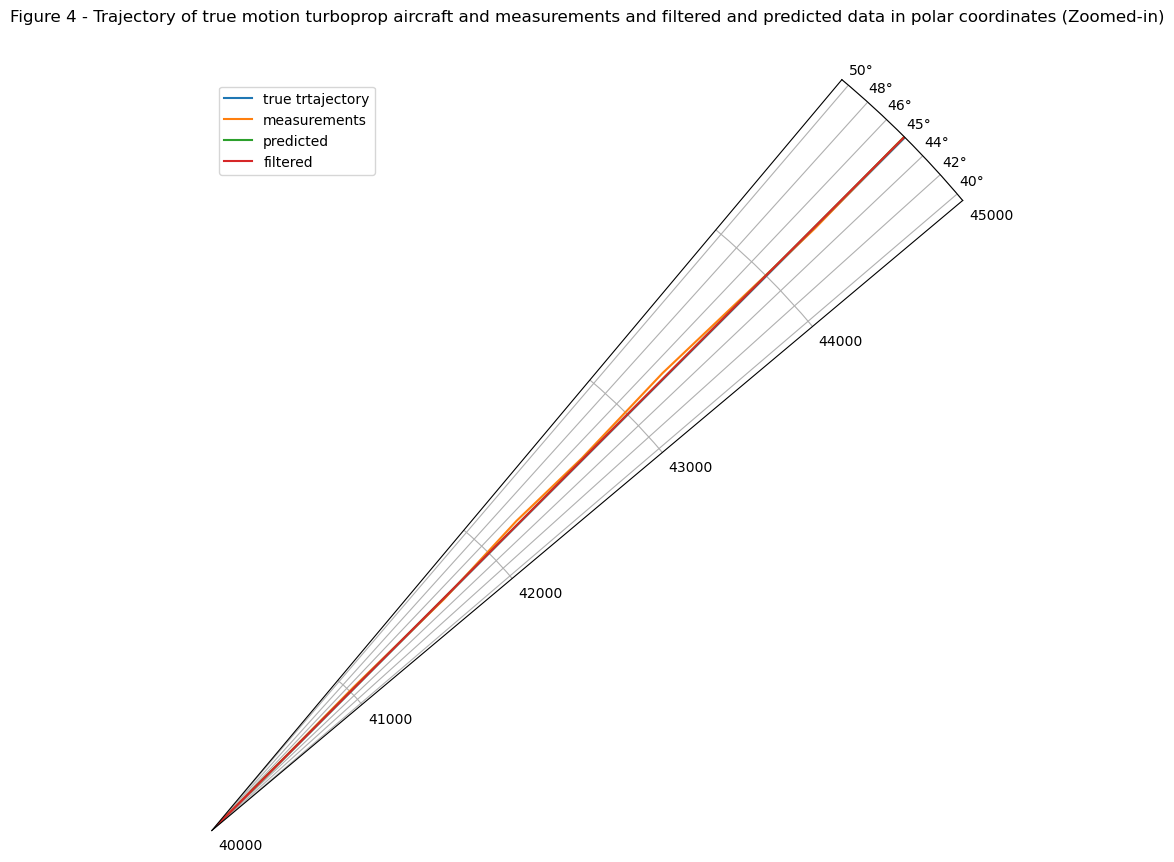

In [43]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta1_plot, D_plot, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_ylim(40000,45000)
ax.set_xlim(40*pi/180,50*pi/180)
ax.set_rlabel_position(90) 
ax.set_title("Figure 4 - Trajectory of true motion turboprop aircraft and measurements and filtered and predicted data in polar coordinates (Zoomed-in)", va='bottom',pad=40)
plt.show()

As we can see, the Kalman filter stabilizes well and filters data efficiently when translating the coordinate system and then get mesurement from 2 observers.

Run the Kalman Filter algorithm for M=500 iterations

In [44]:
#calculate error
M=500
steps=500
errordp=np.zeros((M,steps))
errorbp=np.zeros((M,steps))
fin_errdp=np.zeros(steps)
fin_errbp=np.zeros(steps)
errordf=np.zeros((M,steps))
errorbf=np.zeros((M,steps))
fin_errdf=np.zeros(steps)
fin_errbf=np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=500
    x_real=np.zeros(steps)
    vx_real=np.zeros(steps)
    y_real=np.zeros(steps)
    vy_real=np.zeros(steps)
    t=2
    x_real[0]=1000
    y_real[0]=1000
    vx_real[0]=100
    vy_real[0]=100
    a=np.random.normal(0,0.3,steps)
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+vx_real[i-1]*t+(a[i-1]*(t**2))/2
        vx_real[i]=vx_real[i-1]+a[i-1]*t
        y_real[i]=y_real[i-1]+vy_real[i-1]*t+(a[i-1]*(t**2))/2
        vy_real[i]=vy_real[i-1]+a[i-1]*t
    #trajectory_in_polar_coordinate_system
    D_real=np.zeros(steps)
    beta_real=np.zeros(steps)
    for i in range(0,steps):
        D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
        beta_real[i] = atan(x_real[i]/y_real[i])
    #generating_measurements_of_polar_from_the_first_observer
    D=np.zeros(steps)
    beta1=np.zeros(steps)
    D_plot=np.array([])
    beta1_plot=np.array([])
    for i in range(0,steps-1,2):
        D[i]=D_real[i]+np.random.normal(0,50)
        beta1[i]=beta_real[i]+np.random.normal(0,0.004)
        D_plot=np.append(D_plot,D[i])
        beta1_plot=np.append(beta1_plot,beta1[i])
    #generating_measurements_of_polar_from_the_second_observer
    beta2=np.zeros(steps)
    beta2_plot=np.array([])
    for i in range(3,steps,2):
        beta2[i]=beta_real[i]+np.random.normal(0,0.001)
        beta2_plot=np.append(beta2_plot,beta2[i])
    z1 = np.zeros((steps, 2, 1))
    z2 = np.zeros((steps, 1, 1))
    for i in range(steps):
        z1[i] = np.array([[D[i]], [beta1[i]]])
        z2[i] = np.array([[beta2[i]]])
    #transition matrix
    fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
    #state vector
    X = np.zeros((steps, 4, 1))
    dh1=np.zeros((steps,2,4))
    h1=np.zeros((steps,2,1))
    dh2=np.zeros((steps,1,4))
    h2=np.zeros((steps,1,1))
    #Initial filtered estimate
    X[0]=np.matrix([[D[2]*sin(beta1[2])],[(D[2]*sin(beta1[2])-D[0]*sin(beta1[0]))/(2*t)],[D[2]*cos(beta1[2])],[(D[2]*cos(beta1[2])-D[0]*cos(beta1[0]))/(2*t)]])
    X[1]=np.matrix(X[0])
    X[2]=np.matrix(X[1])
    #Filtration error covariance matrix
    P=np.zeros((steps, 4, 4))
    P[0]=np.matrix([[10**4, 0,0,0], [0, 10**4,0,0],[0,0,10**4,0],[0,0,0,10**4]])
    D_pred=np.zeros(steps)
    D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_pred=np.zeros(steps)
    beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
    D_filt=np.zeros(steps)
    D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_filt=np.zeros(steps)
    beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
    #Covariance matrix
    g=np.matrix([[(t**2)/2,0],[t,0],[0,(t**2)/2],[0,t]])
    K1 = np.zeros((steps, 4, 2))
    K2 = np.zeros((steps, 4, 1))
    R1=np.matrix([[50**2,0],[0,0.004*2]])
    R2=np.matrix([[0.001*2]])
    Q=np.matrix(g@g.T*(0.3**2))
    for i in range(3,steps):
        if i%2==0:
            #step of prediction
            X[i]=fi@X[i-1]
            P[i]=(fi@P[i-1]@fi.T)+Q
            D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
            beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
            #step of filtration
            h1[i]=np.matrix([[sqrt(X[i,0,0]**2+X[i,2,0]**2)],[atan(X[i,0,0]/X[i,2,0])]])
            dh1[i]=np.matrix([[X[i,0,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0,X[i,2,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0],[X[i,2,0]/(X[i,0,0]**2+X[i,2,0]**2),0,-X[i,0,0]/(X[i,0,0]**2+X[i,2,0]**2),0]])
            E=dh1[i]@P[i]@dh1[i].T + R1
            K1[i]=P[i]@dh1[i].T@np.linalg.inv(E)
            X[i]=X[i]+K1[i]@(z1[i]-h1[i])
            P[i]=(np.identity(4)-K1[i]@dh1[i])@P[i]
            D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
            beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
        else:
            #step of prediction
            X[i]=fi@X[i-1]
            P[i]=(fi@P[i-1]@fi.T)+Q
            D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
            beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
            #step of filtration
            h2[i]=np.matrix([[atan(X[i,0,0]/X[i,2,0])]])
            dh2[i]=np.matrix([[X[i,2,0]/(X[i,0,0]**2+X[i,2,0]**2),0,-X[i,0,0]/(X[i,0,0]**2+X[i,2,0]**2),0]])
            E=dh2[i]@P[i]@dh2[i].T + R2
            K2[i]=P[i]@dh2[i].T@np.linalg.inv(E)
            X[i]=X[i]+K2[i]@(z2[i]-h2[i])
            P[i]=(np.identity(4)-K2[i]@dh2[i])@P[i]
            D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
            beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
    for k in range(4,steps):
        errordp[o,k]=(D_real[k]-D_pred[k])**2
        errorbp[o,k]=(beta_real[k]-beta_pred[k])**2
        errordf[o,k]=(D_real[k]-D_filt[k])**2
        errorbf[o,k]=(beta_real[k]-beta_filt[k])**2
for i in range(steps):
    for j in range(M):
        fin_errdp[i]=fin_errdp[i]+((1/(M-1))*errordp[j,i])
        fin_errbp[i]=fin_errbp[i]+((1/(M-1))*errorbp[j,i])
        fin_errdf[i]=fin_errdf[i]+((1/(M-1))*errordf[j,i])
        fin_errbf[i]=fin_errbf[i]+((1/(M-1))*errorbf[j,i])
    fin_errdp[i]=sqrt(fin_errdp[i])
    fin_errbp[i]=sqrt(fin_errbp[i])
    fin_errdf[i]=sqrt(fin_errdf[i])
    fin_errbf[i]=sqrt(fin_errbf[i])

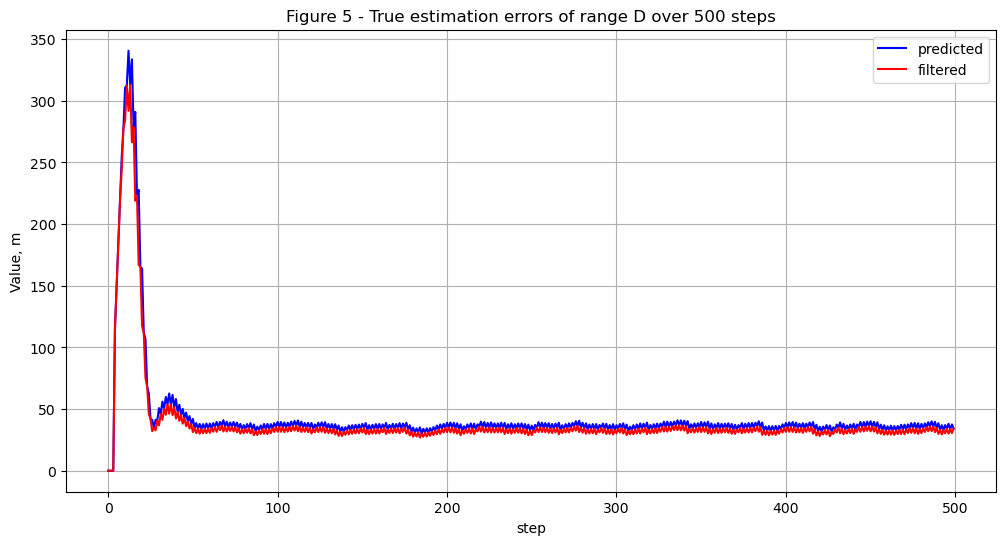

In [45]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errdp, color="blue", label='predicted')
plt.plot(fin_errdf, color="red", label='filtered')
plt.title('Figure 5 - True estimation errors of range D over 500 steps')
plt.xlabel('step')
plt.ylabel('Value, m')
plt.grid()
plt.legend()
plt.show()

Lets's zoom in a plot

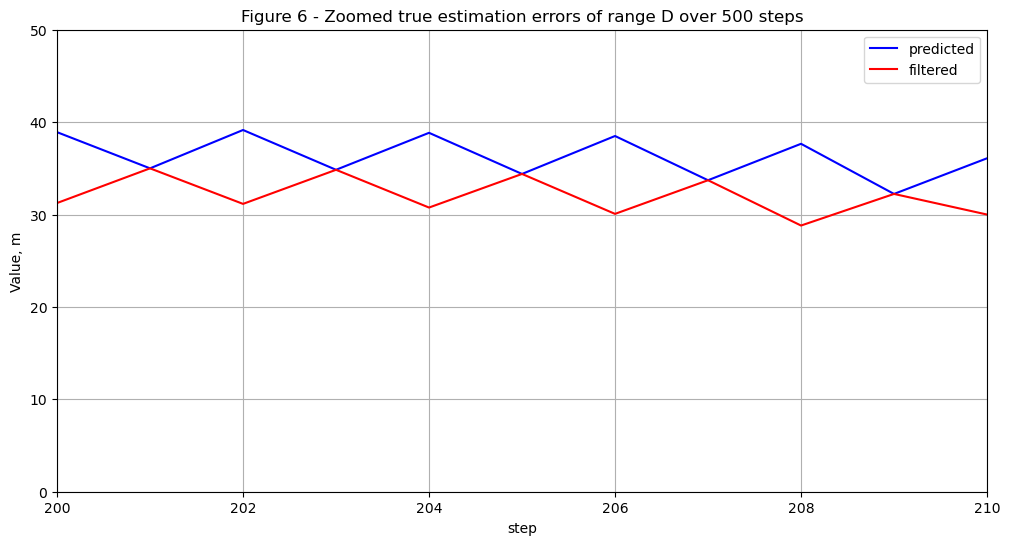

In [46]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errdp, color="blue", label='predicted')
plt.plot(fin_errdf, color="red", label='filtered')
plt.title('Figure 6 - Zoomed true estimation errors of range D over 500 steps')
plt.xlabel('step')
plt.ylabel('Value, m')
plt.ylim(0,50)
plt.xlim(200,210)
plt.grid()
plt.legend()
plt.show()

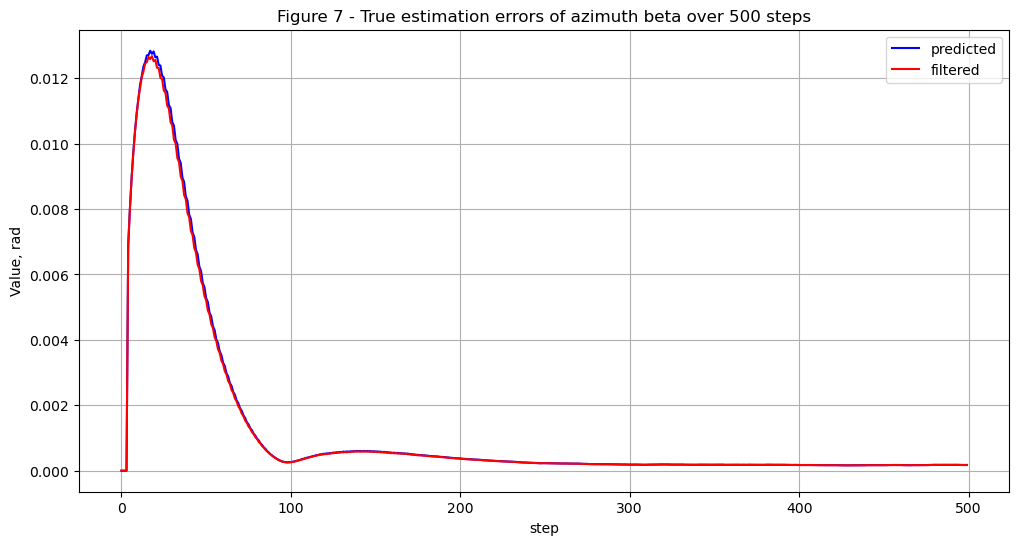

In [47]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errbp, color="blue", label='predicted')
plt.plot(fin_errbf, color="red", label='filtered')
plt.title('Figure 7 - True estimation errors of azimuth beta over 500 steps')
plt.xlabel('step')
plt.ylabel('Value, rad')
plt.grid()
plt.legend()
plt.show()

Lets's give a plot

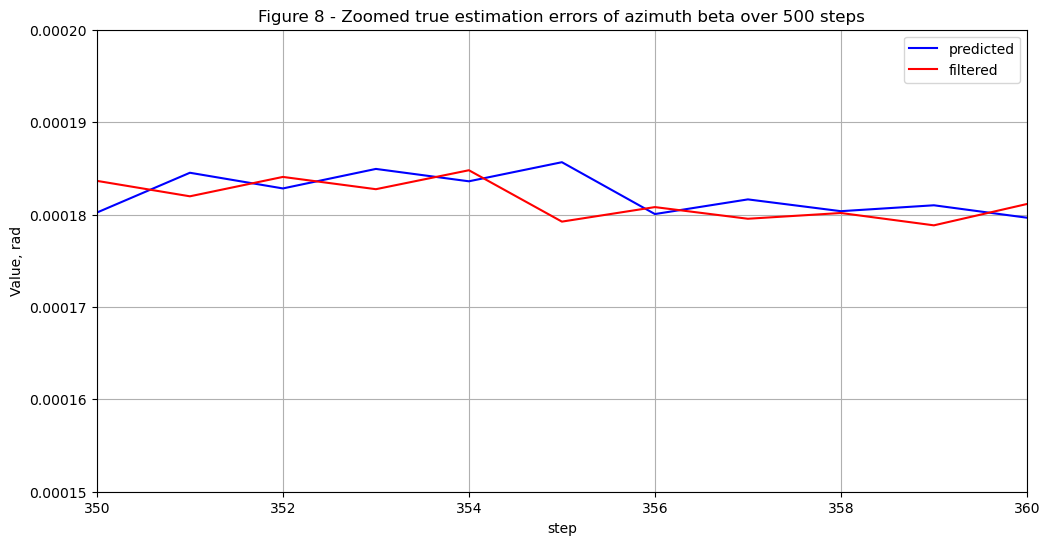

In [48]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errbp, color="blue", label='predicted')
plt.plot(fin_errbf, color="red", label='filtered')
plt.title('Figure 8 - Zoomed true estimation errors of azimuth beta over 500 steps')
plt.xlabel('step')
plt.ylabel('Value, rad')
plt.grid()
plt.xlim(350,360)
plt.ylim(0.00015,0.0002)
plt.legend()
plt.show()

Estimation errors lower than measurement errors of D and beta. Over time, the error in both coordinates decreases, stabilizing at a low level. Thus, the filter is effective and filters the data efficiently. It's also worth noting that the error D at even steps after filtering becomes smaller, as this step receives D measurements, which improve the value of D. The filtering error beta becomes smaller at odd steps, as this step receives beta measurements with less noise. We can also note that for both quantities, the prediction error either decreases or increases relative to the filtering error. This is because the estimations obtained after the filtering step at the previous step have a larger value at the prediction step.

**Conclusion:**

Thus, we've discovered how to fuse data from different sources. We also noticed that with a better coordinate measurement source, we obtain a smaller error value compared to a source with a higher measurement noise value. However, the value obtained in the previous step influences the filtering step in the current step.

**Learning log:**

What we learned:

We learned how to work with data obtained from multiple measurement sources. We also learned how to modify the Kalman filter in this case and which measurements it performs slightly better for.

What difficulties we faced:

We encountered difficulties in developing a Kalman filter in this case, and we are also interested in how to fit the data in this case if we receive data of the same coordinate in the case where they are received at the same time.